In [1]:
!wget -O IBTrACS.csv "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"


--2025-08-06 15:08:02--  https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv
Resolving www.ncei.noaa.gov (www.ncei.noaa.gov)... 205.167.25.177, 205.167.25.172, 205.167.25.178, ...
Connecting to www.ncei.noaa.gov (www.ncei.noaa.gov)|205.167.25.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322721431 (308M) [text/csv]
Saving to: ‘IBTrACS.csv’

IBTrACS.csv         100%[===================>] 307.77M  52.1MB/s    in 6.2s    

2025-08-06 15:08:09 (50.0 MB/s) - ‘IBTrACS.csv’ saved [322721431/322721431]



In [5]:
import pandas as pd

# Load the CSV, skipping unit row
df = pd.read_csv("IBTrACS.csv", skiprows=[1], low_memory=False)

# Use USA columns for lat/lon/wind/pres (they are standardized)
df = df[["SID", "ISO_TIME", "USA_LAT", "USA_LON", "USA_WIND", "USA_PRES", "BASIN"]]
df.columns = ["SID", "ISO_TIME", "LAT", "LON", "WIND", "PRES", "BASIN"]  # rename


In [7]:
# Convert to numeric safely
df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
df = df.dropna(subset=["LAT", "LON", "ISO_TIME"])

# Geographic + Basin filter
df = df[
    (df["BASIN"].isin(["BB", "NI"])) &
    (df["LAT"] >= 0) & (df["LAT"] <= 30) &
    (df["LON"] >= 70) & (df["LON"] <= 105)
]

# Keep first 200 unique storms
selected_sids = df["SID"].unique()[:200]
df_200 = df[df["SID"].isin(selected_sids)].copy()


In [8]:
df_200.to_csv("cyclone_tracks_200.csv", index=False)
print(f"✅ Saved {len(selected_sids)} storms with {len(df_200)} track points.")


✅ Saved 200 storms with 4671 track points.


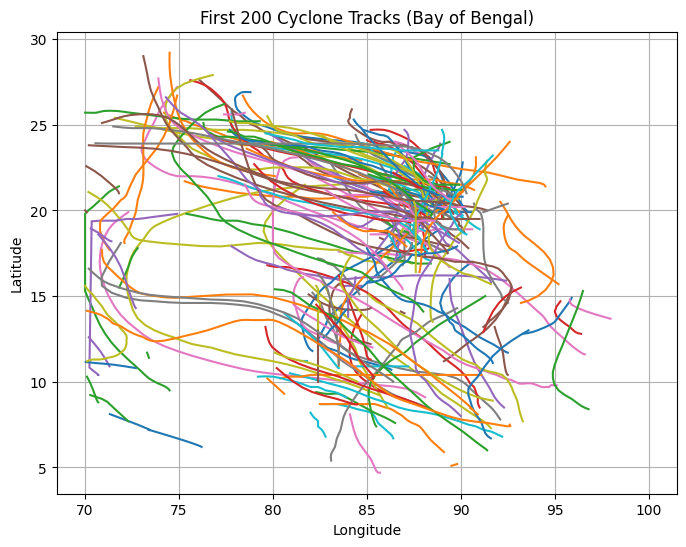

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for sid in selected_sids:
    storm = df_200[df_200["SID"] == sid]
    plt.plot(storm["LON"], storm["LAT"])
    
plt.title("First 200 Cyclone Tracks (Bay of Bengal)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


In [10]:
!pip install cdsapi


In [11]:
import os

cdsapirc = """
url: https://cds.climate.copernicus.eu/api
key: 580f3fa9-e61e-451e-ae3c-4a2794784741
"""

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(cdsapirc.strip())


In [12]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-pressure-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['u_component_of_wind', 'v_component_of_wind'],
        'pressure_level': ['850'],
        'year': '2007',
        'month': '11',
        'day': ['11', '12', '13', '14', '15', '16'],
        'time': ['00:00', '06:00', '12:00', '18:00'],
        'area': [30, 70, 0, 105],  # [N, W, S, E]
        'format': 'netcdf',
    },
    'era5_850_2007_11.nc')


2025-08-06 15:13:01,606 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-06 15:13:02,360 INFO Request ID is e69a25e6-fc11-4693-9c51-a1f968a5048c
2025-08-06 15:13:02,518 INFO status has been updated to accepted
2025-08-06 15:13:16,864 INFO status has been updated to running
2025-08-06 15:13:36,152 INFO status has been updated to successful


9df8520080f6b187768a92428a0c1d98.nc:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

'era5_850_2007_11.nc'

In [13]:
import pandas as pd

# Load your 200 storm tracks
df = pd.read_csv("cyclone_tracks_200.csv")
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

# Extract unique year-months needed
df["year"] = df["ISO_TIME"].dt.year
df["month"] = df["ISO_TIME"].dt.month

unique_year_months = df[["year", "month"]].drop_duplicates().sort_values(["year", "month"]).reset_index(drop=True)

# Display them
print(f"📅 Total months needed: {len(unique_year_months)}")
unique_year_months.head()


📅 Total months needed: 111


,year,month
0,1945,4
1,1945,5
2,1945,6
3,1945,7
4,1945,8


In [14]:
# Filter out months before 1950
unique_year_months_filtered = unique_year_months[unique_year_months["year"] >= 1950]
print(f"📅 Months to download after filtering: {len(unique_year_months_filtered)}")


📅 Months to download after filtering: 69


In [15]:
import cdsapi
from time import sleep

c = cdsapi.Client()

for _, row in unique_year_months_filtered.iterrows():
    year = row["year"]
    month = row["month"]
    filename = f"era5_850_{year}_{month:02d}.nc"

    try:
        print(f"📥 Downloading: {filename}")
        c.retrieve(
            'reanalysis-era5-pressure-levels',
            {
                'product_type': 'reanalysis',
                'variable': ['u_component_of_wind', 'v_component_of_wind'],
                'pressure_level': ['850'],
                'year': str(year),
                'month': f"{month:02d}",
                'day': [f"{d:02d}" for d in range(1, 32)],
                'time': ['00:00', '06:00', '12:00', '18:00'],
                'area': [30, 70, 0, 105],  # [N, W, S, E]
                'format': 'netcdf',
            },
            filename
        )
        sleep(1)
    except Exception as e:
        print(f"⚠️ Error for {filename}: {e}")


2025-08-06 15:13:55,244 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


📥 Downloading: era5_850_1950_04.nc


2025-08-06 15:13:55,586 INFO Request ID is 66aad33f-dfbe-49ee-9178-5a3b0f310d43
2025-08-06 15:13:55,746 INFO status has been updated to accepted
2025-08-06 15:14:04,580 INFO status has been updated to running
2025-08-06 15:14:09,787 INFO status has been updated to successful


3e6c885d0c7dd521452a4256711c714d.nc:   0%|          | 0.00/8.40M [00:00<?, ?B/s]

📥 Downloading: era5_850_1950_05.nc


...

2025-08-06 15:34:10,868 INFO Request ID is a174bd9a-1ae4-42d4-b958-3dfdf5e485bb
2025-08-06 15:34:11,086 INFO status has been updated to accepted
2025-08-06 15:34:25,888 INFO status has been updated to successful


d92f90222e7ed18a0770860f62eb9c04.nc:   0%|          | 0.00/8.53M [00:00<?, ?B/s]

📥 Downloading: era5_850_1959_08.nc


2025-08-06 15:34:29,652 INFO Request ID is 56d4ba15-3749-418d-af63-688f87e88d24
2025-08-06 15:34:29,794 INFO status has been updated to accepted
2025-08-06 15:34:43,746 INFO status has been updated to successful


4882dd8df90fd81add02e15603a4ea56.nc:   0%|          | 0.00/8.48M [00:00<?, ?B/s]

In [16]:
import pandas as pd
import xarray as xr
import os
from tqdm import tqdm

# ✅ 1. Load storm track data
df = pd.read_csv("/kaggle/working/cyclone_tracks_200.csv")
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

# ✅ 2. Load all ERA5 files into a dictionary
era5_cache = {}
print("📦 Loading ERA5 files from /kaggle/working ...")
for file in os.listdir("/kaggle/working"):
    if file.endswith(".nc") and file.startswith("era5_850_"):
        path = os.path.join("/kaggle/working", file)
        key = file.replace(".nc", "")
        era5_cache[key] = xr.open_dataset(path)

print(f"✅ Loaded {len(era5_cache)} ERA5 NetCDF files")

# ✅ 3. Function to determine the correct time dimension name
def get_time_coord_name(dataset):
    """Determine the correct time coordinate name in the dataset"""
    possible_names = ['time', 'valid_time', 'datetime', 't']
    for name in possible_names:
        if name in dataset.coords or name in dataset.dims:
            return name
    raise ValueError(f"No recognized time coordinate found. Available coords: {list(dataset.coords.keys())}")

# ✅ 4. Match each cyclone point with its corresponding ERA5 values
matched_rows = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    year = row["ISO_TIME"].year
    month = row["ISO_TIME"].month
    key = f"era5_850_{year}_{month:02d}"
    
    if key not in era5_cache:
        continue  # Skip if no matching ERA5 file
    
    ds = era5_cache[key]
    
    try:
        # Determine the correct time coordinate name
        time_coord = get_time_coord_name(ds)
        
        # Select data using the correct time coordinate
        ds_time = ds.sel({time_coord: row["ISO_TIME"]}, method="nearest")
        
        # Extract u and v components
        u = ds_time["u"].sel(latitude=row["LAT"], longitude=row["LON"], method="nearest").values.item()
        v = ds_time["v"].sel(latitude=row["LAT"], longitude=row["LON"], method="nearest").values.item()
        
        matched_rows.append({
            "SID": row["SID"],
            "ISO_TIME": row["ISO_TIME"],
            "LAT": row["LAT"],
            "LON": row["LON"],
            "WIND": row["WIND"],
            "PRES": row["PRES"],
            "u850": u,
            "v850": v
        })
        
    except Exception as e:
        print(f"⚠️ Skipping point {row['ISO_TIME']}: {e}")

# ✅ 5. Save the final dataset
df_matched = pd.DataFrame(matched_rows)
df_matched.to_csv("/kaggle/working/features_era5_200.csv", index=False)
print(f"✅ Saved features_era5_200.csv with {len(df_matched)} matched records containing u850 and v850.")

# ✅ 6. Optional: Print summary statistics
if len(df_matched) > 0:
    print(f"\n📊 Summary:")
    print(f"   Total cyclone points processed: {len(df)}")
    print(f"   Successfully matched points: {len(df_matched)}")
    print(f"   Match rate: {len(df_matched)/len(df)*100:.1f}%")
else:
    print("⚠️ No points were successfully matched. Check your data files and coordinates.")

📦 Loading ERA5 files from /kaggle/working ...
✅ Loaded 70 ERA5 NetCDF files


100%|██████████| 4671/4671 [05:07<00:00, 15.19it/s]  

✅ Saved features_era5_200.csv with 2707 matched records containing u850 and v850.

📊 Summary:
   Total cyclone points processed: 4671
   Successfully matched points: 2707
   Match rate: 58.0%


In [17]:
import pandas as pd
import numpy as np

# Load matched ERA5 + IBTrACS dataset
df = pd.read_csv("features_era5_200.csv")
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

# 1. Wind magnitude at 850 hPa
df["wind_speed_850"] = np.sqrt(df["u850"]**2 + df["v850"]**2)

# 2. Steering wind direction (angle in degrees)
df["steering_direction"] = np.degrees(np.arctan2(df["v850"], df["u850"]))

# 3. Coriolis parameter: f = 2 * Omega * sin(phi)
# Omega = 7.2921 × 10^-5 rad/s (Earth's angular velocity)
df["coriolis"] = 2 * 7.2921e-5 * np.sin(np.radians(df["LAT"]))

# 4. Optional: Δlat/Δlon as learning target (next step)
# We'll do this in Part 6

# Preview the new features
df[["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]].head()


,LAT,LON,u850,v850,wind_speed_850,steering_direction,coriolis
0,5.40000,83.1000,-4.751266,-8.227219,9.500614,-120.006683,0.000014
1,5.60250,83.0775,-2.617783,-5.251892,5.868148,-116.493759,0.000014
2,5.80000,83.1000,-3.561142,-4.931580,6.082944,-125.833420,0.000015
3,5.99251,83.1925,-2.784958,-3.445908,4.430606,-128.944896,0.000015
4,6.20000,83.3000,-3.161911,-3.399033,4.642317,-132.930152,0.000016


In [18]:
df.to_csv("features_engineered_200.csv", index=False)
print("✅ Saved features_engineered_200.csv with new physics-aware features.")


✅ Saved features_engineered_200.csv with new physics-aware features.


In [19]:
import pandas as pd

# Load your feature-engineered data
df = pd.read_csv("features_engineered_200.csv")
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

# Sort by storm and time
df = df.sort_values(by=["SID", "ISO_TIME"]).reset_index(drop=True)

# Compute Δlat and Δlon using groupby
df["next_LAT"] = df.groupby("SID")["LAT"].shift(-1)
df["next_LON"] = df.groupby("SID")["LON"].shift(-1)

df["dLAT"] = df["next_LAT"] - df["LAT"]
df["dLON"] = df["next_LON"] - df["LON"]

# Drop rows where next_LAT or next_LON is NaN (i.e., last point of each storm)
df = df.dropna(subset=["dLAT", "dLON"]).reset_index(drop=True)

# Optionally drop next_LAT and next_LON
df.drop(columns=["next_LAT", "next_LON"], inplace=True)

# Save final training dataset
df.to_csv("training_data_200.csv", index=False)
print("✅ Labeled and saved training_data_200.csv with Δlat and Δlon")


✅ Labeled and saved training_data_200.csv with Δlat and Δlon


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

# Load your dataset
df = pd.read_csv("training_data_200.csv")

# Input and output columns
feature_cols = ["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]
target_cols = ["dLAT", "dLON"]

# Extract arrays
X = df[feature_cols].values
y = df[target_cols].values

# Normalize inputs (important for neural nets)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


In [21]:
import torch.nn as nn

class CycloneTrackNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # Output: Δlat, Δlon
        )

    def forward(self, x):
        return self.net(x)


In [22]:
from torch.utils.data import DataLoader, TensorDataset

# Setup
model = CycloneTrackNet(input_size=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)

# Training loop
for epoch in range(1, 51):  # 50 epochs
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = sum(loss_fn(model(xb), yb).item() for xb, yb in val_loader)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 2.4389 | Val Loss: 0.2480
Epoch 02 | Train Loss: 1.8090 | Val Loss: 0.2322
Epoch 03 | Train Loss: 1.6343 | Val Loss: 0.2258
Epoch 04 | Train Loss: 1.5520 | Val Loss: 0.2226
Epoch 05 | Train Loss: 1.5010 | Val Loss: 0.2197
Epoch 06 | Train Loss: 1.4415 | Val Loss: 0.2239
Epoch 07 | Train Loss: 1.4165 | Val Loss: 0.2126
Epoch 08 | Train Loss: 1.3712 | Val Loss: 0.2086
Epoch 09 | Train Loss: 1.3448 | Val Loss: 0.2066
Epoch 10 | Train Loss: 1.3441 | Val Loss: 0.2021
Epoch 11 | Train Loss: 1.3107 | Val Loss: 0.2036
Epoch 12 | Train Loss: 1.2870 | Val Loss: 0.1989
Epoch 13 | Train Loss: 1.2662 | Val Loss: 0.1988
Epoch 14 | Train Loss: 1.3295 | Val Loss: 0.1983
Epoch 15 | Train Loss: 1.2497 | Val Loss: 0.1968
Epoch 16 | Train Loss: 1.2198 | Val Loss: 0.1943
Epoch 17 | Train Loss: 1.2142 | Val Loss: 0.1927
Epoch 18 | Train Loss: 1.2015 | Val Loss: 0.1902
Epoch 19 | Train Loss: 1.1899 | Val Loss: 0.1981
Epoch 20 | Train Loss: 1.1819 | Val Loss: 0.1946
Epoch 21 | Train Los

In [23]:
torch.save(model.state_dict(), "track_model.pt")

import joblib
joblib.dump(scaler, "feature_scaler.save")
print("✅ Model and scaler saved.")


✅ Model and scaler saved.


In [24]:
import numpy as np
import torch

def forecast_storm_track(model, scaler, initial_input, initial_position, n_steps=8):
    """
    Forecast storm positions for n_steps × 6 hours using an autoregressive model.
    
    Parameters:
        model: trained PyTorch model
        scaler: fitted sklearn scaler used during training
        initial_input: 1D array of input features (unscaled) at time t
        initial_position: [lat, lon] at time t
        n_steps: number of 6h steps to predict (default = 8 for 48h)
    
    Returns:
        List of predicted positions: [[lat0, lon0], [lat1, lon1], ..., [latN, lonN]]
    """
    model.eval()
    track = [initial_position]
    features = initial_input.copy()

    for step in range(n_steps):
        # Scale features
        x_scaled = scaler.transform([features])
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32)

        # Predict Δlat, Δlon
        with torch.no_grad():
            delta = model(x_tensor).numpy()[0]

        # Update position
        last_pos = track[-1]
        next_lat = last_pos[0] + delta[0]
        next_lon = last_pos[1] + delta[1]
        track.append([next_lat, next_lon])

        # OPTIONAL (for now skipped): update ERA5 features at new location
        # features = update_environmental_data(next_lat, next_lon, ...)

        # Keep same ERA5 features — only position changes
        features[0] = next_lat
        features[1] = next_lon

    return track


In [26]:
import pandas as pd
import joblib
import torch

# Load model + scaler
model = CycloneTrackNet(input_size=7)
model.load_state_dict(torch.load("track_model.pt"))
model.eval()

scaler = joblib.load("feature_scaler.save")

# Load dataset
df = pd.read_csv("training_data_200.csv")

# Pick one storm point (e.g., first row)
row = df.iloc[0]
initial_position = [row["LAT"], row["LON"]]
initial_input = row[["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]].values

# Run forecast
predicted_track = forecast_storm_track(model, scaler, initial_input, initial_position, n_steps=8)


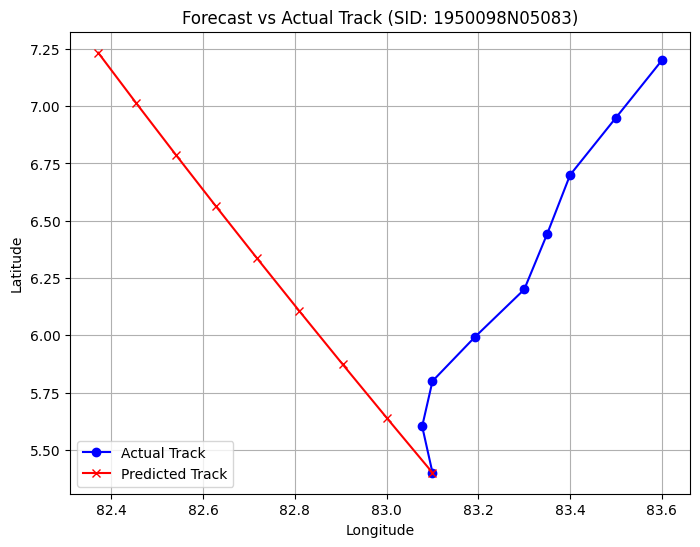

In [27]:
import matplotlib.pyplot as plt

# Actual track for the same SID
sid = row["SID"]
true_track = df[df["SID"] == sid].sort_values("ISO_TIME")
true_positions = true_track[["LAT", "LON"]].values[:9]  # first 9 steps (0h to 48h)

pred_lat, pred_lon = zip(*predicted_track)
true_lat, true_lon = zip(*true_positions)

plt.figure(figsize=(8, 6))
plt.plot(true_lon, true_lat, marker='o', label="Actual Track", color='blue')
plt.plot(pred_lon, pred_lat, marker='x', label="Predicted Track", color='red')
plt.legend()
plt.title(f"Forecast vs Actual Track (SID: {sid})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


In [28]:
# You likely don't need to install anything on Kaggle for this
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib


In [29]:
# Load dataset
df = pd.read_csv("training_data_200.csv")

# Features and target
feature_cols = ["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]
target_cols = ["dLAT", "dLON"]

X = df[feature_cols].values
y = df[target_cols].values

# Scale inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

# Torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Loaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)


In [30]:
class CycloneTrackNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # Δlat, Δlon
        )
    
    def forward(self, x):
        return self.net(x)


In [31]:
class PINNLoss(nn.Module):
    def __init__(self, lambda_steering=1.0, lambda_coriolis=0.2):
        super().__init__()
        self.lambda_steering = lambda_steering
        self.lambda_coriolis = lambda_coriolis
        self.mse = nn.MSELoss()

    def forward(self, pred_delta, true_delta, inputs):
        # Regular MSE loss
        data_loss = self.mse(pred_delta, true_delta)

        # Wind alignment
        u = inputs[:, 2]
        v = inputs[:, 3]
        wind_mag = torch.sqrt(u**2 + v**2) + 1e-6
        wind_unit = torch.stack([v / wind_mag, u / wind_mag], dim=1)

        pred_mag = torch.norm(pred_delta, dim=1, keepdim=True) + 1e-6
        pred_unit = pred_delta / pred_mag

        steering_loss = 1.0 - torch.sum(pred_unit * wind_unit, dim=1).mean()

        # Coriolis penalty
        coriolis = inputs[:, 6]
        lat_penalty = torch.mean((pred_delta[:, 0] * coriolis)**2)

        return data_loss + self.lambda_steering * steering_loss + self.lambda_coriolis * lat_penalty


In [32]:
model = CycloneTrackNet(input_size=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = PINNLoss(lambda_steering=1.0, lambda_coriolis=0.2)

epochs = 50

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb, xb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = sum(loss_fn(model(xb), yb, xb).item() for xb, yb in val_loader)

    print(f"Epoch {epoch:02d} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Loss: 18.1556 | Val Loss: 0.7192
Epoch 02 | Train Loss: 4.5325 | Val Loss: 0.6101
Epoch 03 | Train Loss: 4.0702 | Val Loss: 0.5703
Epoch 04 | Train Loss: 3.7651 | Val Loss: 0.5727
Epoch 05 | Train Loss: 3.6745 | Val Loss: 0.5597
Epoch 06 | Train Loss: 3.5779 | Val Loss: 0.5405
Epoch 07 | Train Loss: 3.5231 | Val Loss: 0.5436
Epoch 08 | Train Loss: 3.4755 | Val Loss: 0.5124
Epoch 09 | Train Loss: 3.3475 | Val Loss: 0.5145
Epoch 10 | Train Loss: 3.3213 | Val Loss: 0.5011
Epoch 11 | Train Loss: 3.2906 | Val Loss: 0.5017
Epoch 12 | Train Loss: 3.2882 | Val Loss: 0.5005
Epoch 13 | Train Loss: 3.2548 | Val Loss: 0.4931
Epoch 14 | Train Loss: 3.2615 | Val Loss: 0.4962
Epoch 15 | Train Loss: 3.2647 | Val Loss: 0.5111
Epoch 16 | Train Loss: 3.2432 | Val Loss: 0.4889
Epoch 17 | Train Loss: 3.1887 | Val Loss: 0.4982
Epoch 18 | Train Loss: 3.1691 | Val Loss: 0.4943
Epoch 19 | Train Loss: 3.1434 | Val Loss: 0.4823
Epoch 20 | Train Loss: 3.1477 | Val Loss: 0.4775
Epoch 21 | Train Lo

In [33]:
torch.save(model.state_dict(), "track_model_pinn.pt")
joblib.dump(scaler, "feature_scaler_pinn.save")
print("✅ Saved PINN model and scaler.")


✅ Saved PINN model and scaler.


In [34]:
import torch
import joblib

# Define model architecture again
class CycloneTrackNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

# Load baseline model
model_base = CycloneTrackNet(input_size=7)
model_base.load_state_dict(torch.load("track_model.pt"))
model_base.eval()

# Load PINN model
model_pinn = CycloneTrackNet(input_size=7)
model_pinn.load_state_dict(torch.load("track_model_pinn.pt"))
model_pinn.eval()

# Load scalers
scaler_base = joblib.load("feature_scaler.save")
scaler_pinn = joblib.load("feature_scaler_pinn.save")


In [35]:
def forecast_track(model, scaler, initial_input, initial_position, n_steps=8):
    track = [initial_position]
    current_features = initial_input.copy()

    for _ in range(n_steps):
        x_scaled = scaler.transform([current_features])
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32)
        with torch.no_grad():
            delta = model(x_tensor).numpy()[0]

        last_pos = track[-1]
        next_pos = [last_pos[0] + delta[0], last_pos[1] + delta[1]]
        track.append(next_pos)

        # Update only lat/lon, keep ERA5 fixed
        current_features[0] = next_pos[0]
        current_features[1] = next_pos[1]

    return track


In [36]:
import pandas as pd

# Load dataset
df = pd.read_csv("training_data_200.csv")

# Pick a specific cyclone
sid = df["SID"].unique()[0]  # pick first storm
storm_df = df[df["SID"] == sid].sort_values("ISO_TIME")

# Initial conditions
initial_row = storm_df.iloc[0]
initial_position = [initial_row["LAT"], initial_row["LON"]]
initial_input = initial_row[["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]].values

# Forecast both
track_base = forecast_track(model_base, scaler_base, initial_input.copy(), initial_position, n_steps=8)
track_pinn = forecast_track(model_pinn, scaler_pinn, initial_input.copy(), initial_position, n_steps=8)

# Get actual positions (first 9 points)
actual_positions = storm_df[["LAT", "LON"]].values[:9]


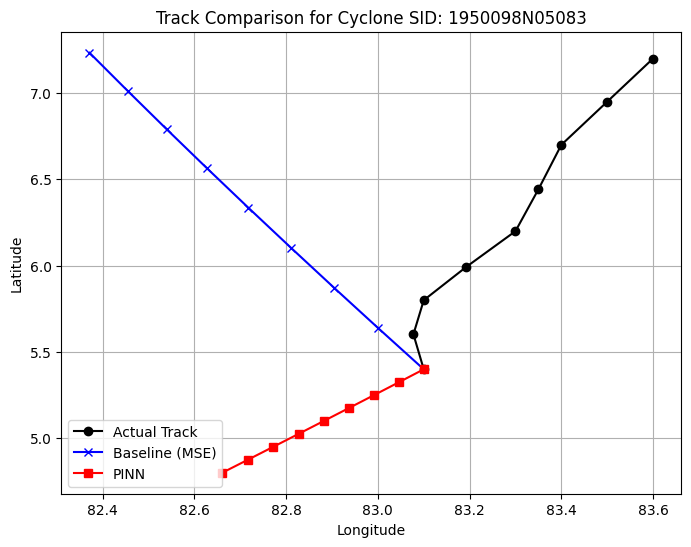

In [37]:
import matplotlib.pyplot as plt

# Unpack
base_lat, base_lon = zip(*track_base)
pinn_lat, pinn_lon = zip(*track_pinn)
true_lat, true_lon = zip(*actual_positions)

plt.figure(figsize=(8, 6))
plt.plot(true_lon, true_lat, marker='o', label="Actual Track", color='black')
plt.plot(base_lon, base_lat, marker='x', label="Baseline (MSE)", color='blue')
plt.plot(pinn_lon, pinn_lat, marker='s', label="PINN", color='red')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Track Comparison for Cyclone SID: {sid}")
plt.grid(True)
plt.legend()
plt.show()


In [39]:
!pip install haversine --quiet


In [40]:
from haversine import haversine


In [41]:
def compute_haversine_errors(model, scaler, df, model_name="PINN", n_steps=8):
    errors = []

    for sid in df["SID"].unique():
        storm_df = df[df["SID"] == sid].sort_values("ISO_TIME").reset_index(drop=True)

        if len(storm_df) < n_steps + 1:
            continue  # Skip short storms

        # Initial position + features
        initial_row = storm_df.iloc[0]
        actual_track = storm_df[["LAT", "LON"]].values[:n_steps + 1]

        initial_position = [initial_row["LAT"], initial_row["LON"]]
        initial_input = initial_row[["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]].values

        pred_track = forecast_track(model, scaler, initial_input, initial_position, n_steps)

        # Compute Haversine error at each step
        for step in range(n_steps + 1):
            true_pos = tuple(actual_track[step])
            pred_pos = tuple(pred_track[step])
            error_km = haversine(true_pos, pred_pos)
            errors.append((step * 6, error_km, model_name))  # time (in hours), error, tag

    return pd.DataFrame(errors, columns=["Hour", "Error_km", "Model"])


In [42]:
df = pd.read_csv("training_data_200.csv")

# Run for baseline model
baseline_errors = compute_haversine_errors(model_base, scaler_base, df, model_name="Baseline")

# Run for PINN model
pinn_errors = compute_haversine_errors(model_pinn, scaler_pinn, df, model_name="PINN")

# Combine
all_errors = pd.concat([baseline_errors, pinn_errors])


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

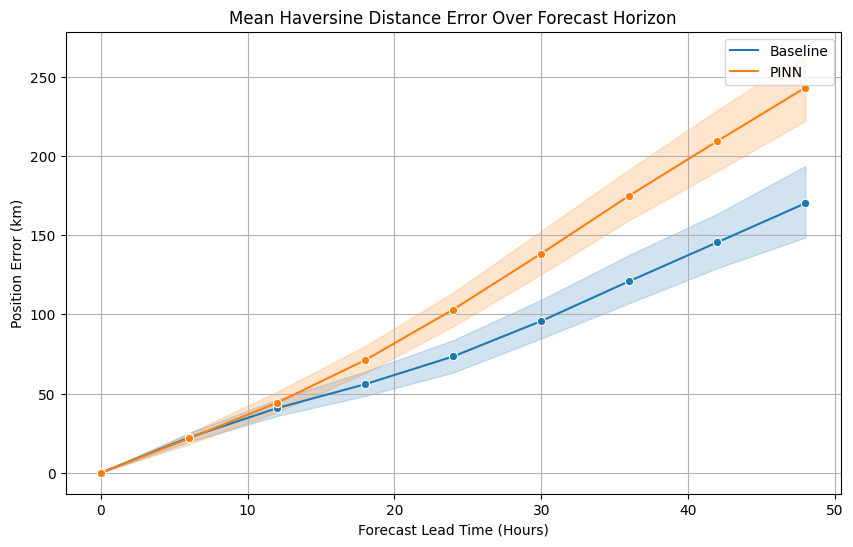

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=all_errors, x="Hour", y="Error_km", hue="Model", marker="o")
plt.title("Mean Haversine Distance Error Over Forecast Horizon")
plt.ylabel("Position Error (km)")
plt.xlabel("Forecast Lead Time (Hours)")
plt.grid(True)
plt.legend()
plt.show()


In [55]:
df = pd.read_csv("training_data_200.csv")

# See all storms in 2007
sidr_candidates = df[df["ISO_TIME"].str.contains("2007")]["SID"].unique()
print(sidr_candidates)


[]


In [56]:
# Load the CSV again just in case
df = pd.read_csv("training_data_200.csv")

# Convert ISO_TIME to datetime (if not already)
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

# Now extract all SIDs from 2007
sidr_candidates = df[df["ISO_TIME"].dt.year == 2007]["SID"].unique()
print(sidr_candidates)


[]


In [58]:
import pandas as pd

# Load full IBTrACS CSV (or subset you downloaded)
df = pd.read_csv("/kaggle/working/IBTrACS.csv", low_memory=False)

# Convert time
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")

# Filter Sidr (November 2007, Bay of Bengal)
df_sidr = df[
    (df["ISO_TIME"].dt.year == 2007) &
    (df["ISO_TIME"].dt.month == 11) &
    (df["BASIN"] == "BB")
]

# Optional: filter by name if available
if "NAME" in df.columns:
    df_sidr = df_sidr[df_sidr["NAME"].str.upper() == "SIDR"]

# Drop missing positions
df_sidr = df_sidr.dropna(subset=["LAT", "LON", "ISO_TIME"]).reset_index(drop=True)

print(df_sidr[["SID", "ISO_TIME", "LAT", "LON"]])


/tmp/ipykernel_36/4237881964.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")


Empty DataFrame
Columns: [SID, ISO_TIME, LAT, LON]
Index: []


In [60]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-pressure-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['u_component_of_wind', 'v_component_of_wind'],
        'pressure_level': ['850'],
        'year': '2007',
        'month': '11',
        'day': [f"{i:02d}" for i in range(1, 31)],
        'time': [f"{h:02d}:00" for h in range(0, 24)],
        'format': 'netcdf',
    },
    'era5_850_2007_11.nc'
)


2025-08-06 16:34:04,449 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-06 16:34:04,807 INFO Request ID is 646c82ed-bebc-4d52-b4b1-c531b8653bde
2025-08-06 16:34:05,243 INFO status has been updated to accepted
2025-08-06 16:36:00,387 INFO status has been updated to successful


2502286e02d19d2b182cc92c9312e30d.nc:   0%|          | 0.00/2.66G [00:00<?, ?B/s]

'era5_850_2007_11.nc'

In [66]:
import xarray as xr

ds = xr.open_dataset("era5_850_2007_11.nc")

u_list, v_list = [], []

for _, row in df_sidr.iterrows():
    try:
        sel = ds.sel(time=row["ISO_TIME"], method="nearest")
        u = sel["u"].sel(latitude=row["LAT"], longitude=row["LON"], method="nearest").values.item()
        v = sel["v"].sel(latitude=row["LAT"], longitude=row["LON"], method="nearest").values.item()
        u_list.append(u)
        v_list.append(v)
    except Exception as e:
        print(f"Skipping {row['ISO_TIME']} due to {e}")
        u_list.append(None)
        v_list.append(None)

df_sidr["u850"] = u_list
df_sidr["v850"] = v_list

# Drop invalid points
df_sidr = df_sidr.dropna(subset=["u850", "v850"]).reset_index(drop=True)


In [68]:
import numpy as np

df_sidr["wind_speed_850"] = np.sqrt(df_sidr["u850"]**2 + df_sidr["v850"]**2)
df_sidr["steering_direction"] = np.degrees(np.arctan2(df_sidr["v850"], df_sidr["u850"]))
df_sidr["coriolis"] = 2 * 7.2921e-5 * np.sin(np.radians(df_sidr["LAT"]))


In [69]:
initial_row = df_sidr.iloc[0]
initial_position = [initial_row["LAT"], initial_row["LON"]]
initial_input = initial_row[["LAT", "LON", "u850", "v850", "wind_speed_850", "steering_direction", "coriolis"]].values

# Forecast (use either baseline or PINN model here)
sidr_pred_pinn = forecast_track(model_pinn, scaler_pinn, initial_input.copy(), initial_position, n_steps=8)
sidr_true = df_sidr[["LAT", "LON"]].values[:9]


IndexError: single positional indexer is out-of-bounds